# Joint Recurrence Plots Analysis - Lag Synchronization

## Samuel Jaramillo

### Research question
1. Compare the recurrence plot methods for detecting phase, generalised, and complete synchronisation (lag synchronisation is included).

2. Prepare an overview of the ability of the measures derived from cross- and joint recurrence plots and from tau-recurrence rate.

3. (Bonus) improve the tau-recurrence rate measure (CPR).

In [4]:
import numpy as np
import pandas as pd
import recurrence as rec
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.integrate import solve_ivp

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [4]:
#Recurrence matrix updated version
def recurrence_matrix(timeseries, epsilon, transpose = False):

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                if current_value <= epsilon:
                    current_row.append(1)
                else:
                    current_row.append(0)
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        return d_matrix <= epsilon

#Recurrence matrix updated version
def recurrence_matrix_fan(timeseries, RR, transpose = False):
    nn_i = int(RR*len(timeseries))

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)

            current_row = np.array(current_row)
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        for i in range(d_matrix.shape[0]):
            current_row = d_matrix[i]
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1

            d_matrix[i] = current_row   

        return d_matrix 
    
#Recurrence matrix updated version
def cross_recurrence_matrix(timeseries1, timeseries2, epsilon, transpose = False):

    if timeseries1.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries1)):
            current_row = []
            for j in range(len(timeseries1)):
                current_value = np.abs(timeseries1[i] - timeseries2[j])
                if current_value <= epsilon:
                    current_row.append(1)
                else:
                    current_row.append(0)
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries1 = timeseries1.T
            timeseries2 = timeseries2.T

        d_matrix = cdist(timeseries1, timeseries2, metric = 'euclidean')

        return d_matrix <= epsilon
    

#Find epsilon
def optimal_epsilon(timeseries, rrate, transpose = False):
    #1-dimensional time series
    if timeseries.ndim == 1:
        d_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)  
            d_matrix.append(current_row)
    
        d_matrix = np.array(d_matrix)

    # N-dimensional time series (N>1)
    else:
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))
    #Colapse distance matrices and sort its values
    d_vector = d_matrix.flatten()

    #Sort values
    d_vector= np.sort(d_vector)

    n = int(len(d_vector)*rrate)

    return d_vector[n]

#Find CRP epsilon
def CRP_optimal_epsilon(timeseries1, timeseries2, rrate, transpose = False):
    #1-dimensional time series
    if timeseries1.ndim == 1:
        d_matrix = []
        for i in range(len(timeseries1)):
            current_row = []
            for j in range(len(timeseries1)):
                current_value = np.abs(timeseries1[i] - timeseries2[j])
                current_row.append(current_value)  
            d_matrix.append(current_row)
    
        d_matrix = np.array(d_matrix)

    # N-dimensional time series (N>1)
    else:
        #Create distance matrix
        if transpose == True:
            timeseries1 = timeseries1.T
            timeseries2 = timeseries2.T

        d_matrix = cdist(timeseries1, timeseries2, metric = 'euclidean')
    #Colapse distance matrices and sort its values
    d_vector = d_matrix.flatten()

    #Sort values
    d_vector= np.sort(d_vector)

    n = int(len(d_vector)*rrate)

    return d_vector[n]

## Recurrence plot comparison

In [6]:
#Import models
nosynch1 = pd.read_csv('LS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('LS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('LS_synch1.csv').to_numpy()

synch2 = pd.read_csv('LS_synch2.csv').to_numpy()


In [8]:
#View the individual recurrence plots
#No synch
rec_nosynch1 = RecurrencePlot(nosynch1, recurrence_rate=0.05, metric="euclidean")
rm_nosynch1 = rec_nosynch1.recurrence_matrix()

rec_nosynch2 = RecurrencePlot(nosynch2, recurrence_rate=0.05, metric="euclidean")
rm_nosynch2 = rec_nosynch2.recurrence_matrix()

#Synch
rec_synch1 = RecurrencePlot(synch1, recurrence_rate=0.05, metric="euclidean")
rm_synch1 = rec_synch1.recurrence_matrix()

rec_synch2 = RecurrencePlot(synch2, recurrence_rate=0.05, metric="euclidean")
rm_synch2 = rec_synch2.recurrence_matrix()


Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


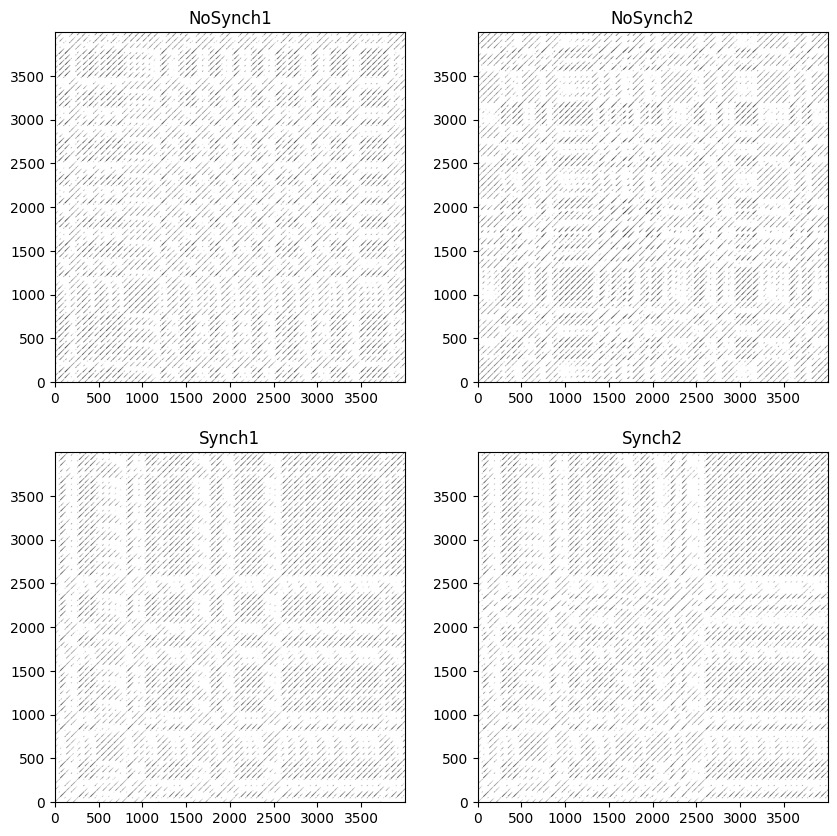

In [16]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(10, 10))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

- Plots with no synch don't share the different regimes, synched plots do (identified by the large squares of homogeneous behaviour)
- We should expect the JRP to be more crowded for the synched case


In [17]:
#Compute JRPs
#No synch
LS_JR_nosynch = JointRecurrencePlot(nosynch1, nosynch2, recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"))

RMat_LS_nosynch = LS_JR_nosynch.recurrence_matrix()

#Synch
LS_JR_synch = JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"))

RMat_LS_synch = LS_JR_synch.recurrence_matrix()


Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


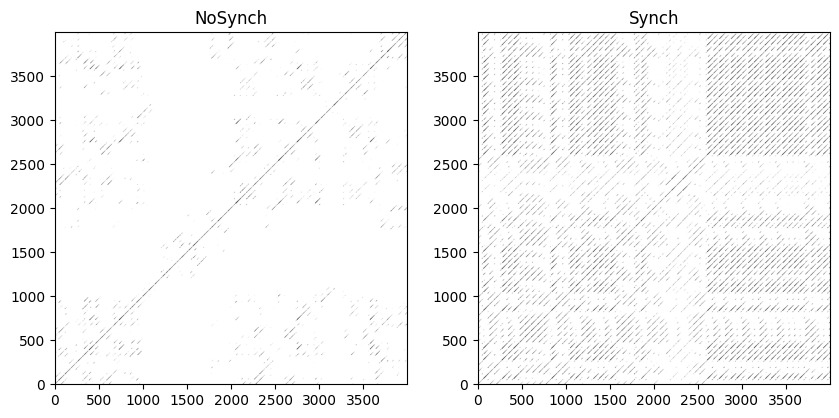

In [ ]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title('NoSynch')

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title('Synch')


plt.show()

- JRP clearly shows sensitivity to LS. NoSynch plot is almost empty, while the Synch plot shows how both time series share different regimes.

Let's check the $S(0)$

In [ ]:
print('S(0) NoSynch', LS_JR_nosynch.recurrence_rate()/0.05)
print('S(0) Synch', LS_JR_synch.recurrence_rate()/0.05)

S(0) NoSynch) 0.10389249999999998
S(0) Synch) 0.7487625


## $S(\tau)$ analysis

Question: Is $S(\tau)$ sensible to the coupling in LS?


Step 1: Check $S(\tau)$ for current timeseries

In [26]:
lagged_JR_synch = [JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"), lag = i) for i in range(40)]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

In [27]:
s_tau_synch = [lagged_JR_synch[i].recurrence_rate()/0.05 for i in range(len(lagged_JR_synch))]

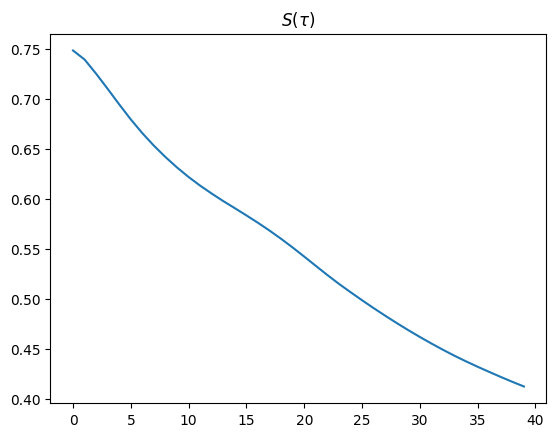

In [28]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau_synch)
axs.set_title(r'$S(\tau)$')

plt.show()

- $S(\tau)$ decreases as lag increases, but that doesn't tell us much about the ability of $S(\tau)$ to detect LS. 

- Let's use the metric defined by Marwan (2007)

$$
JPR = \max_{\tau} \frac{S(\tau) - RR}{1 - RR}.
$$

we vary coupling and see how JPR changes with it. 

In [72]:
# Parameters
a = 0.25
b = 0.25
c = 40


# Coupled rossler
def coupled_rossler(t, state, eps):
    x1, y1, z1, x2, y2, z2 = state

    dxdt1 = -y1 - z1
    dydt1 = x1 + a * y1
    dzdt1 = b + z1 * (x1 - c)

    dxdt2 = -y2 - z2 + eps * (x1 - x2)
    dydt2 = x2 + a * y2
    dzdt2 = b + z2 * (x2 - c)

    return [dxdt1, dydt1, dzdt1, dxdt2, dydt2, dzdt2]

In [73]:
eps = np.arange(0, 0.4, 0.01)   # coupling strength

t_span = (0, 500)
t_eval = np.linspace(0, 500, 5000)

init = [1,1,1, 2,2,2]

sols = [solve_ivp(coupled_rossler, t_span, init, t_eval=t_eval, args=(eps[i],)) for i in range(len(eps))]

In [74]:
#Separate models
synch1_varied_coupling = [sols[i].y[:3].T[1000:] for i in range(len(sols))]
synch2_varied_coupling = [sols[i].y[3:].T[1000:] for i in range(len(sols))]

In [75]:
#Normalize them
synch1_varied_coupling = [(synch1_varied_coupling[i] - np.mean(synch1_varied_coupling, axis = 0)) / np.std(synch1_varied_coupling, axis = 0) for i in range(len(synch1_varied_coupling))]
synch2_varied_coupling = [(synch2_varied_coupling[i] - np.mean(synch2_varied_coupling, axis = 0)) / np.std(synch2_varied_coupling, axis = 0) for i in range(len(synch2_varied_coupling))]

In [76]:
from tqdm import tqdm

JPR_list = []

for i in tqdm(range(len(synch1_varied_coupling))):
    lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"), lag = j) for j in range(30)]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.05 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.05)/(1 - 0.05)

    JPR_list.append(JPR_i)


  0%|          | 0/40 [00:00<?, ?it/s]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

  2%|▎         | 1/40 [01:15<49:01, 75.42s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

  5%|▌         | 2/40 [02:31<48:07, 75.98s/it]

...

 95%|█████████▌| 38/40 [1:06:04<02:40, 80.05s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

 98%|█████████▊| 39/40 [1:07:22<01:19, 79.64s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

100%|██████████| 40/40 [1:08:41<00:00, 103.03s/it]


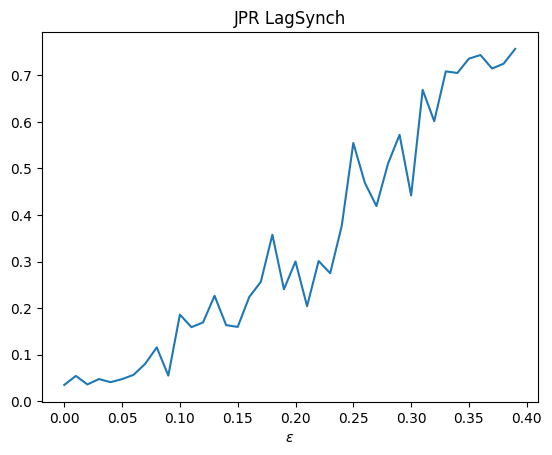

In [77]:
fig, axs = plt.subplots()

#Plot
axs.plot(eps,JPR_list)
axs.set_xlabel(r"$\epsilon$")
axs.set_title(r'JPR LagSynch')

plt.show()

- JPR is clearly sensitive to coupling. It's values are lower than those of $S(\tau)$ alone, but what we care about here is the clearly increasing trend as coupling increases.
- The lag $\tau$ in the $S(\tau)$ measure was originally introduced to detect LS (Marwan, 2007), so it makes sense that it's able to detect it. 
- Cases can be imagined where $S(0)$ might not detect LS but $S(\tau)$ will. For example, consider two plots with the same spacing with diagonals, but where the recurrences of one are shifted towards the intervals with no recurrence of the other. $S(0)$ would be low in this case. However, as we shift the lag, the recurrences will also move forward (inside the diagonal) until they'll coincide perfectly with those of the other plot, reaching a high value of $S(\tau)$ (see notebook notes, 19/03/26).

Marwan (2007) actually introduces the lag in $S(\tau)$ to be able to detect LS also. 

## Structured analysis after meeting

In [5]:
import pandas as pd

In [6]:
#Import models
nosynch1 = pd.read_csv('timeseries/LS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('timeseries/LS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('timeseries/LS_synch1.csv').to_numpy()

synch2 = pd.read_csv('timeseries/LS_synch2.csv').to_numpy()

In [7]:
#View the individual recurrence plots
#No synch
rec_nosynch1 = RecurrencePlot(nosynch1, recurrence_rate=0.1, metric="euclidean")
rm_nosynch1 = rec_nosynch1.recurrence_matrix()

rec_nosynch2 = RecurrencePlot(nosynch2, recurrence_rate=0.1, metric="euclidean")
rm_nosynch2 = rec_nosynch2.recurrence_matrix()

#Synch
rec_synch1 = RecurrencePlot(synch1, recurrence_rate=0.1, metric="euclidean")
rm_synch1 = rec_synch1.recurrence_matrix()

rec_synch2 = RecurrencePlot(synch2, recurrence_rate=0.1, metric="euclidean")
rm_synch2 = rec_synch2.recurrence_matrix()

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


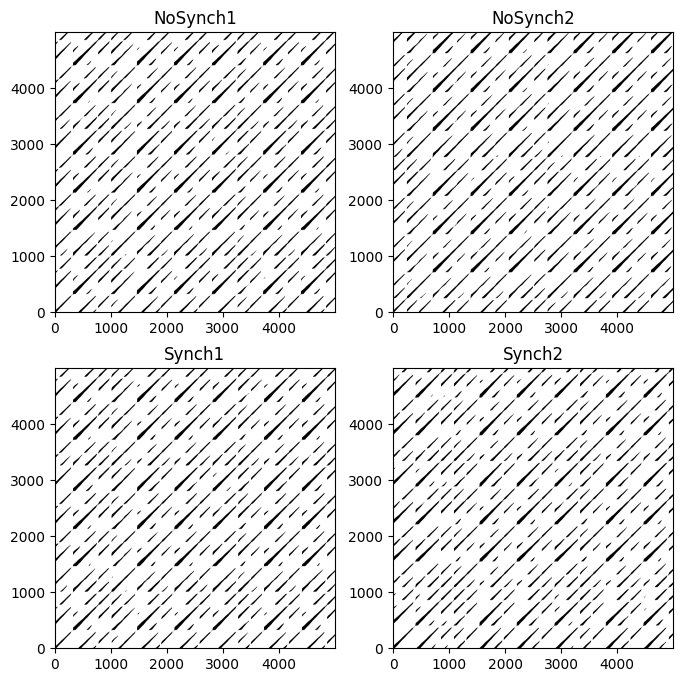

In [81]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

- No evident distinction can be made between them. At most, individual recurrences are different, but differences in the spacing between diagonals in NoSynch plots are not visible. 

In [8]:
#Compute JRPs
#No synch
LS_JR_nosynch = JointRecurrencePlot(nosynch1, nosynch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_nosynch = LS_JR_nosynch.recurrence_matrix()

#Synch
LS_JR_synch = JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_synch = LS_JR_synch.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


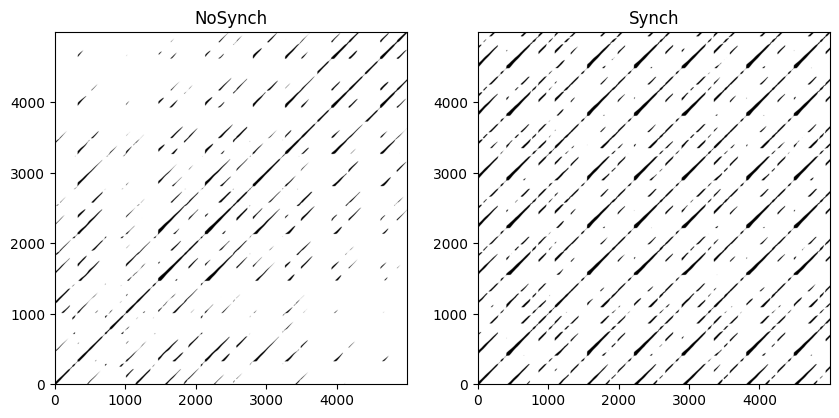

In [83]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title('NoSynch')

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title('Synch')


plt.show()

- Synched JRP is clearly more crowded than non-Synched JRP.
- Recurrence differences in NoSynched become more pronounced towards upper left and lower right corners, corresponding to recurrences between points at the beginning and towards the end of the time series. 

In [9]:
lagged_JR_synch = [JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = i) for i in range(120)]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

In [10]:
s_tau_synch = [lagged_JR_synch[i].recurrence_rate()/0.1 for i in range(len(lagged_JR_synch))]

In [11]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_JR_synch[max_lag]

RMat_max_JRP_tau  = max_JRP_tau.recurrence_matrix()

In [12]:
print('JRP NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('JRP(0)',s_tau_synch[0])
print('JRP(tau)',max(s_tau_synch))

JRP NoSynch 0.281976
JRP(0) 0.6202632
JRP(tau) 0.8632196


In [13]:
import string

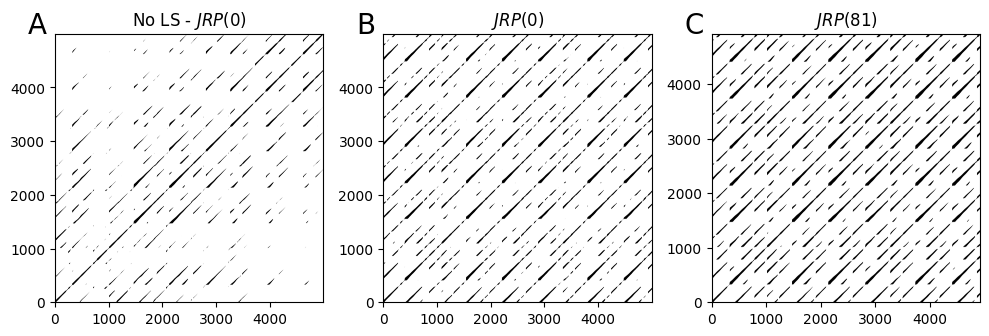

In [10]:
#Visualize
fig, axs = plt.subplots(1,3,figsize=(10, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No LS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)

axs[2].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[2].set_title(r'$JRP({})$'.format(max_lag))
axs[2].text(-0.1, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
fig.savefig('plots/JRPs_LS.pdf', dpi=300)

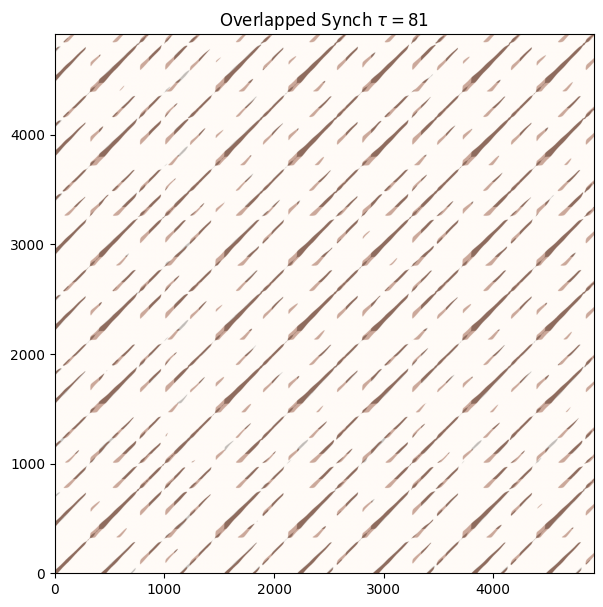

In [106]:
#Visualize
fig, axs = plt.subplots(figsize=(7, 7))

axs.imshow(RMat_LS_synch, origin='lower', cmap = 'binary', alpha = 0.4)

axs.imshow(RMat_max_JRP_tau, origin='lower', cmap = 'Oranges', alpha = 0.4)
axs.set_title(r'Overlapped Synch $\tau = {}$'.format(max_lag))


plt.show()

#### $S(\tau)$ analysis

In [14]:
print('S(0) NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('S(0) Synch', LS_JR_synch.recurrence_rate()/0.1)

S(0) NoSynch 0.281976
S(0) Synch 0.6202632


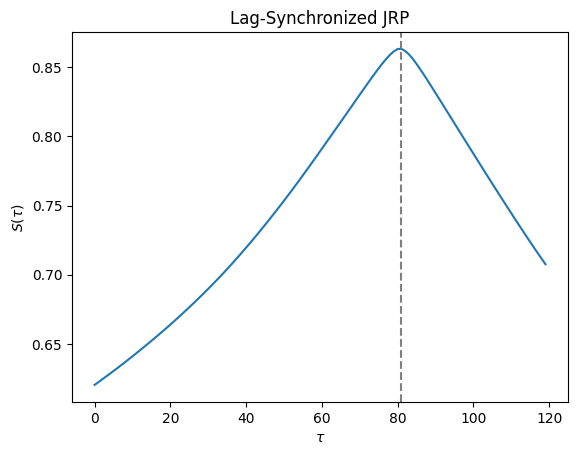

In [17]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau_synch)
axs.set_xlabel(r'$\tau$')
axs.set_ylabel(r'$S(\tau)$')
axs.axvline(max_lag, ls = '--', color = 'gray')
axs.set_title(r'Lag-Synchronized JRP')

plt.show()
fig.savefig('plots/LS_S_tau.pdf', dpi=300)

Evaluation of sensitivity of $S(\tau)$ to coupling

In [18]:
def coupled_rossler_delay(a=0.2, b=0.2, c=5.7,
                         k=0.5, tau=2.0,
                         dt=0.01, steps=10000):

    import numpy as np

    delay_steps = int(tau / dt)

    # initialize arrays
    xd = np.zeros(steps)
    yd = np.zeros(steps)
    zd = np.zeros(steps)

    xr = np.zeros(steps)
    yr = np.zeros(steps)
    zr = np.zeros(steps)

    # initial conditions
    xd[0], yd[0], zd[0] = 1, 1, 1
    xr[0], yr[0], zr[0] = 0, 0, 0

    for i in range(steps - 1):

        # drive
        xd[i+1] = xd[i] + dt * (-yd[i] - zd[i])
        yd[i+1] = yd[i] + dt * (xd[i] + a * yd[i])
        zd[i+1] = zd[i] + dt * (b + zd[i] * (xd[i] - c))

        # delayed signal
        if i > delay_steps:
            xd_tau = xd[i - delay_steps]
        else:
            xd_tau = xd[0]

        # response
        xr[i+1] = xr[i] + dt * (-yr[i] - zr[i] + k * (xd_tau - xr[i]))
        yr[i+1] = yr[i] + dt * (xr[i] + a * yr[i])
        zr[i+1] = zr[i] + dt * (b + zr[i] * (xr[i] - c))
    
    driver = np.array([xd, yd, zd])
    response = np.array([xr, yr, zr])

    return driver, response

In [23]:
ks = np.linspace(0, 0.5, 40)

In [24]:
'''
from tqdm import tqdm

JPR_list = []


for i in tqdm(range(len(ks))):
    d, r = coupled_rossler_delay(dt = 0.025, k=ks[i])

    d = d.T[5000:]
    r = r.T[5000:]

    #Vary lag to cover wider range
    lagged_JR_synch_i = [JointRecurrencePlot(d, r, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = 3*j) for j in range(30)]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)
'''

'\nfrom tqdm import tqdm\n\nJPR_list = []\n\n\nfor i in tqdm(range(len(ks))):\n    d, r = coupled_rossler_delay(dt = 0.025, k=ks[i])\n\n    d = d.T[5000:]\n    r = r.T[5000:]\n\n    #Vary lag to cover wider range\n    lagged_JR_synch_i = [JointRecurrencePlot(d, r, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = 3*j) for j in range(30)]\n    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])\n\n\n    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)\n\n    JPR_list.append(JPR_i)\n'

In [25]:
'''
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("LS_JPR_list.csv", index=False)
'''

'\n#Save to avoid computing it again\nJPR_list_saved = pd.DataFrame(JPR_list)\n\n# save the dataframe as a csv file\nJPR_list_saved.to_csv("LS_JPR_list.csv", index=False)\n'

In [26]:
#Import models
JPR_list = pd.read_csv('LS_JPR_list.csv').to_numpy()

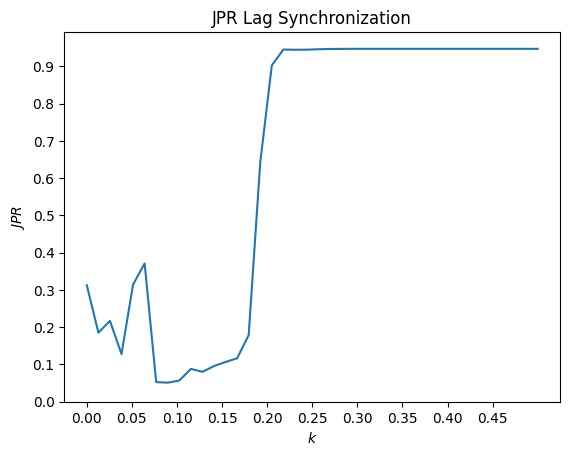

In [27]:
fig, axs = plt.subplots()

#Plot
axs.plot(ks,JPR_list)
axs.set_xlabel(r"$k$")
axs.set_yticks(np.arange(0,1,0.1))
axs.set_xticks(np.arange(0,0.5,0.05))
axs.set_ylabel(r"$JPR$")
axs.set_title(r'JPR Lag Synchronization')

plt.show()
fig.savefig('plots/LS_JPR.png')

In [28]:

ks = np.linspace(0, 0.5, 40)

In [29]:
from tqdm import tqdm

CPR_list = []

for i in tqdm(range(len(ks))):
    d, r = coupled_rossler_delay(dt = 0.025, k=ks[i])

    d = d.T[5000:]
    r = r.T[5000:]

    rp_drive = RecurrencePlot(d, metric="euclidean", recurrence_rate=0.1)
    rp_response = RecurrencePlot(r, metric="euclidean", recurrence_rate=0.1)

    RP_drive = rp_drive.recurrence_matrix()
    RP_response = rp_response.recurrence_matrix()

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

  0%|          | 0/40 [00:00<?, ?it/s]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  2%|▎         | 1/40 [00:04<02:41,  4.15s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  5%|▌         | 2/40 [00:08<02:36,  4.12s/it]

...

 95%|█████████▌| 38/40 [02:42<00:08,  4.37s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


 98%|█████████▊| 39/40 [02:47<00:04,  4.41s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


100%|██████████| 40/40 [02:51<00:00,  4.28s/it]


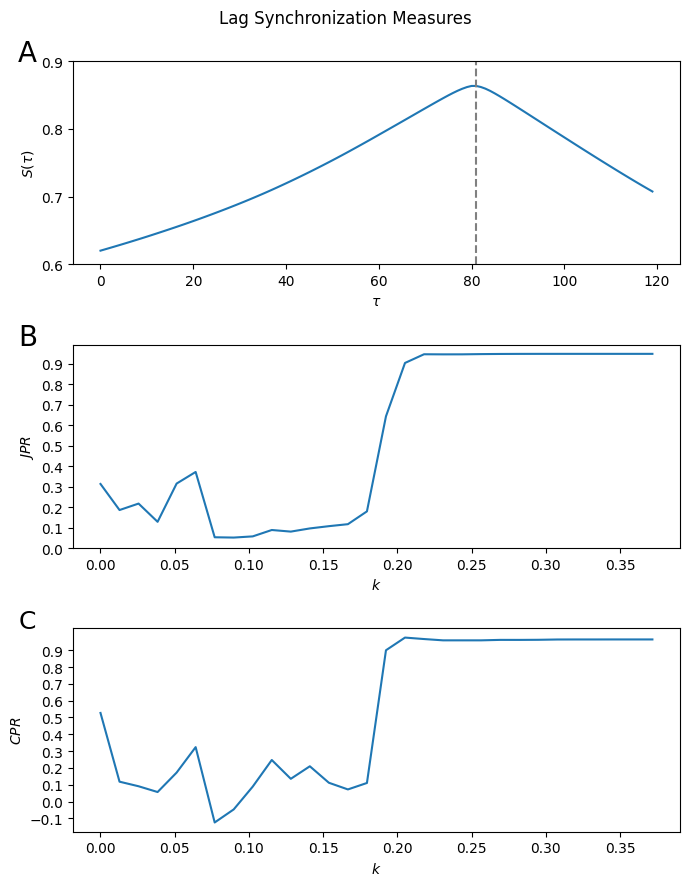

In [46]:
fig, axs = plt.subplots(3,1,figsize=(7, 9))

#S tau
axs[0].plot(s_tau_synch)
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$S(\tau)$')
axs[0].set_yticks(np.arange(0.6,0.9,0.1))
axs[0].axvline(max_lag, ls = '--', color = 'gray')
axs[0].text(-0.09, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

#JPR
axs[1].plot(ks[:-10],JPR_list[:-10])
axs[1].set_xlabel(r"$k$")
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,0.4,0.05))
axs[1].set_ylabel(r"$JPR$")
axs[1].text(-0.09, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)


#CPR
axs[2].plot(ks[:-10],CPR_list[:-10])
axs[2].set_xlabel(r"$k$")
axs[2].set_yticks(np.arange(-0.1,1,0.1))
axs[2].set_xticks(np.arange(0,0.4,0.05))
axs[2].set_ylabel(r"$CPR$")
axs[2].text(-0.09, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=18)

fig.suptitle('Lag Synchronization Measures')

plt.tight_layout()
plt.show()


fig.savefig('plots/LS_JPRandCPR.pdf', dpi=300)

In [31]:
print(CPR_list[-1], JPR_list[-1])

0.9642338215991358 [0.947152]
